# Calc Offset v1
Load car parquet data with selected columns

In [1]:
import pandas as pd
import json
import os
from glm_model_test import load_glm_model, predict_glm
from default_value_handler import check_missing_values, apply_all_defaults
import matplotlib.pyplot as plt


# Helper function to hide personal path prefix
HOME_PREFIX = '/Users/Mach/'
def short_path(path):
    return path.replace(HOME_PREFIX, '~/')

In [2]:
# Load config
with open('config.json', 'r') as f:
    config = json.load(f)

parquet_path = config['car_parquet_path']
print(f"Parquet path: {short_path(parquet_path)}")

vin_bsst_path = config['vin_bsst_path']
print(f"VIN BSST path: {short_path(vin_bsst_path)}")

bsst_glm_path = config['BSST_GLM_path']
print(f"BSST GLM path: {short_path(bsst_glm_path)}")

zip_geodensity_csv = config['zip_geodensity_csv']
print(f"Zip geodensity path: {short_path(zip_geodensity_csv)}")

output_path = config['car_with_dep_factor']
print(f"Output path: {short_path(output_path)}")


Parquet path: ~/dev/aps/data/2026_Dmodel_data/master_dataset_car.parquet
VIN BSST path: ~/dev/aps/data/2026_Dmodel_data/VIN_BSST.parquet
BSST GLM path: ~/dev/aps/data/2026_Dmodel_data/BSST_json
Zip geodensity path: ~/dev/aps/data/2026_Dmodel_data/geo_2017_2023_20260128.csv
Output path: ~/dev/aps/data/2026_Dmodel_data/car_with_dep_factor.parquet


In [3]:
# Define columns to load
columns = [
    'cef_est_curr_mi_grp_imps', # 'odometer',
    'zip_pop_dens',#'geo_pop_density_ntile',
    'dml_year_imps', #'CALC_VEH_AGE' = 2025 - 'dml_year_imps' ,
    'vc_msrp_impa',
    'st_raw',
    'insstate',
    'dml_make_raw',
    'vin',
    'vin_date', 
    'zip'
]

# Load parquet file with selected columns
df = pd.read_parquet(parquet_path, columns=columns)
print(f"Data loaded successfully!")

Data loaded successfully!


In [4]:
print(f"Records with dml_year_imps = -999: {(df['dml_year_imps'] == -999).sum():,}")
df = df[df['dml_year_imps'] != -999]
print(f"Records remaining after excluding -999: {len(df):,}")

Records with dml_year_imps = -999: 2,509
Records remaining after excluding -999: 22,703,333


In [5]:
# Display basic info
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)

Shape: (22703333, 10)

Columns: ['cef_est_curr_mi_grp_imps', 'zip_pop_dens', 'dml_year_imps', 'vc_msrp_impa', 'st_raw', 'insstate', 'dml_make_raw', 'vin', 'vin_date', 'zip']

Data types:
cef_est_curr_mi_grp_imps    float64
zip_pop_dens                float64
dml_year_imps               float64
vc_msrp_impa                float64
st_raw                       object
insstate                     object
dml_make_raw                 object
vin                          object
vin_date                     object
zip                          object
dtype: object


In [6]:
df_zip_geodensity = pd.read_csv(zip_geodensity_csv)
df_zip_geodensity.head()

,zip,census_year,geo_vacant_pct,geo_median_home_value,geo_median_pop_age,geo_unemployment_rate,geo_pop_density,geo_exists
0,501,2019,0.045554,354800.0,43.6,4.1,NaN,True
1,501,2020,0.043054,366600.0,42.4,2.7,NaN,True
2,501,2021,0.035264,381600.0,39.7,3.8,NaN,True
3,501,2022,0.022532,450900.0,39.8,2.6,NaN,True
4,501,2023,0.022126,475600.0,40.0,2.5,NaN,True


In [7]:
# Calculate geo_pop_density_ntile using zip, geo_pop_density, and state
# Based on logic from 20260511 Entry Level Car Value GLM.ipynb

# Step 1: Add REC_CNT column
df['REC_CNT'] = 1

# Step 2: Aggregate record counts by zip
zip_counts = df.groupby(['zip']).agg({'REC_CNT': 'count'}).reset_index()
print(f"Unique zips in data: {len(zip_counts):,}")

# Step 3: Prepare geo data - ensure unique zips
geo = df_zip_geodensity[['zip', 'geo_pop_density']].copy()
geo = geo.loc[geo['geo_pop_density'].notna()]
geo = geo.drop_duplicates(subset=['zip'])  # IMPORTANT: Ensure unique zips
print(f"Unique zips in geo data: {len(geo):,}")

# Step 4: Merge geo data with zip counts
geo = geo.merge(zip_counts, how='left')
geo['REC_CNT'] = geo['REC_CNT'].fillna(0)  # Fill NaN with 0 for zips not in our data

# Step 5: Sort by geo_pop_density and calculate ntile
geo.sort_values(by='geo_pop_density', inplace=True)
geo['cumsum'] = geo['REC_CNT'].cumsum()
total_records = geo['cumsum'].max()
print(f"Total records in cumsum: {total_records:,}")

if total_records > 0:
    geo['geo_pop_density_ntile'] = round(geo['cumsum'] / total_records, 2) * 100
else:
    geo['geo_pop_density_ntile'] = 50  # Default if no records

# IMPORTANT: Ensure ntile is within 0-100 range
geo['geo_pop_density_ntile'] = geo['geo_pop_density_ntile'].clip(0, 100)
geo = geo[['zip', 'geo_pop_density_ntile']]

# Step 6: Merge ntile to main dataframe
df_len_before = len(df)
df = df.merge(geo, how='left')
df_len_after = len(df)
if df_len_before != df_len_after:
    print(f"WARNING: Merge changed row count from {df_len_before:,} to {df_len_after:,}")

# Step 7: Calculate state default (average ntile per state)
gpdn_default_state = df.groupby(['st_raw']).agg({'geo_pop_density_ntile': 'mean'}).reset_index()
gpdn_default_state.rename(columns={'geo_pop_density_ntile': 'geo_pop_density_ntile_state_default'}, inplace=True)
gpdn_default_state['geo_pop_density_ntile_state_default'] = round(gpdn_default_state['geo_pop_density_ntile_state_default'], 0)

# Step 8: Merge state default and fill missing values
df = df.merge(gpdn_default_state, how='left')
df['geo_pop_density_ntile'] = df['geo_pop_density_ntile'].fillna(df['geo_pop_density_ntile_state_default']).fillna(50)
del df['geo_pop_density_ntile_state_default']
del df['REC_CNT']

print(f"\ngeo_pop_density_ntile calculated for {len(df):,} records")
print(f"geo_pop_density_ntile range: {df['geo_pop_density_ntile'].min()} to {df['geo_pop_density_ntile'].max()}")
print(f"Missing values: {df['geo_pop_density_ntile'].isna().sum()}")

# Validation check: geo_pop_density_ntile must be within 0-100
out_of_range = ((df['geo_pop_density_ntile'] < 0) | (df['geo_pop_density_ntile'] > 100)).sum()
if out_of_range > 0:
    print(f"\n⚠️ ERROR: {out_of_range:,} records have geo_pop_density_ntile outside 0-100 range!")
    raise ValueError(f"geo_pop_density_ntile has {out_of_range} values outside 0-100 range")
else:
    print(f"\n✓ Validation passed: All geo_pop_density_ntile values are within 0-100 range")

Unique zips in data: 31,645
Unique zips in geo data: 28,585
Total records in cumsum: 14,779,305.0

geo_pop_density_ntile calculated for 22,703,333 records
geo_pop_density_ntile range: 0.0 to 100.0
Missing values: 0

✓ Validation passed: All geo_pop_density_ntile values are within 0-100 range


In [8]:
# Preview data
df.head()

,cef_est_curr_mi_grp_imps,zip_pop_dens,dml_year_imps,vc_msrp_impa,st_raw,insstate,dml_make_raw,vin,vin_date,zip,geo_pop_density_ntile
0,0.0,5156.602537,2005.0,19594.0,OH,OH,HYUNDAI,KMHWF35H45A178516,KMHWF35H45A178516_04-26-2022,43613,91.0
1,210000.0,4747.258202,2005.0,19594.0,TX,TX,HYUNDAI,KMHWF35H75A128502,KMHWF35H75A128502_11-21-2020,78758,57.0
2,70000.0,400.767060,2013.0,19545.0,CA,CA,HYUNDAI,KMHD35LE5DU068088,KMHD35LE5DU068088_05-03-2020,92315,30.0
3,60000.0,1161.108842,2013.0,18545.0,GA,GA,HYUNDAI,KMHD35LE5DU047158,KMHD35LE5DU047158_05-30-2021,30519,63.0
4,0.0,2918.222119,2013.0,18545.0,NJ,NJ,HYUNDAI,KMHD35LE5DU082332,KMHD35LE5DU082332_11-17-2019,8075,79.0


In [9]:

temp_age = config['model_year'] - df['dml_year_imps']
suspicious_mask = (temp_age >= 20) & (df['cef_est_curr_mi_grp_imps'] > 0) & (df['cef_est_curr_mi_grp_imps'] < 25000)
print(f"Suspicious records (age >= 18, 0 < odo < 22K): {suspicious_mask.sum():,} ({suspicious_mask.mean()*100:.4f}%)")
print(temp_age[suspicious_mask].value_counts().sort_index().head(15))


Suspicious records (age >= 18, 0 < odo < 22K): 25,773 (0.1135%)
dml_year_imps
20.0    5699
21.0    4194
22.0    3225
23.0    2808
24.0    2584
25.0    1687
26.0    1288
27.0     963
28.0     554
29.0     445
30.0     351
31.0     271
32.0     259
33.0     189
34.0     132
Name: count, dtype: int64


In [10]:
df[df['dml_year_imps'] <= 2006][['dml_year_imps', 'cef_est_curr_mi_grp_imps']].describe()



,dml_year_imps,cef_est_curr_mi_grp_imps
count,5.116573e+06,5.116573e+06
mean,2.001730e+03,7.679278e+04
std,4.482798e+00,8.813233e+04
min,1.981000e+03,0.000000e+00
25%,2.000000e+03,0.000000e+00
50%,2.003000e+03,4.000000e+04
75%,2.005000e+03,1.500000e+05
max,2.006000e+03,1.020000e+06


In [11]:
print(f"Records with dml_year_imps = -999: {(df['dml_year_imps'] == -999).sum():,}")
print(f"Records with dml_year_imps <= 0: {(df['dml_year_imps'] <= 0).sum():,}")

Records with dml_year_imps = -999: 0
Records with dml_year_imps <= 0: 0


In [12]:
# Count records where cef_est_curr_mi_grp_imps = 0
zero_count = (df['cef_est_curr_mi_grp_imps'] == 0).sum()
total_count = len(df)
print(f"Records with cef_est_curr_mi_grp_imps = 0: {zero_count:,}")
print(f"Total records: {total_count:,}")
print(f"Percentage: {zero_count/total_count*100:.2f}%")



Records with cef_est_curr_mi_grp_imps = 0: 8,447,023
Total records: 22,703,333
Percentage: 37.21%


In [13]:
odo_median = df['cef_est_curr_mi_grp_imps'].median()
print(odo_median) 

40000.0


In [14]:
# Load VIN_BSST parquet file
df_bsst = pd.read_parquet(vin_bsst_path, columns=['VIN', 'BODY_STYLE_SEGMENT_BODY_TYPE'])
print(f"VIN_BSST loaded: {df_bsst.shape}")
df_bsst.head()

VIN_BSST loaded: (26310207, 2)


,VIN,BODY_STYLE_SEGMENT_BODY_TYPE
0,1B3HB48B88D587726,Basic Economy (Car)
1,1C6RR7ST4JS291614,Fullsize Pickup
2,5J6RW2H84LA025942,Sport Utility
3,JN8AS5MV5AW136578,Sport Utility
4,5NMS3CAD0LH161245,Sport Utility


In [15]:
# Merge BODY_STYLE_SEGMENT_BODY_TYPE to df using VIN
df = df.merge(df_bsst, left_on='vin', right_on='VIN', how='left')
print(f"After merge shape: {df.shape}")

After merge shape: (27052200, 13)


In [16]:
# Create BSST_formatted column
# Transform: "Basic Economy (Car)" -> "Basic_Economy_Car_GLM"
df['BSST_formatted'] = (df['BODY_STYLE_SEGMENT_BODY_TYPE']
    .str.replace(' ', '_')
    .str.replace('_(', '_', regex=False)
    .str.replace(')', '', regex=False) + '_GLM')

# Preview the formatting
print("Sample BSST_formatted values:")
print(df[['BODY_STYLE_SEGMENT_BODY_TYPE', 'BSST_formatted']].drop_duplicates().head(10))

Sample BSST_formatted values:
      BODY_STYLE_SEGMENT_BODY_TYPE         BSST_formatted
0              Lower Midsize (Car)  Lower_Midsize_Car_GLM
2              Basic Economy (Car)  Basic_Economy_Car_GLM
10               Entry Level (Car)    Entry_Level_Car_GLM
15              Basic Luxury (Car)   Basic_Luxury_Car_GLM
23             Upper Midsize (Car)  Upper_Midsize_Car_GLM
59              Basic Sporty (Car)   Basic_Sporty_Car_GLM
90             Middle Luxury (Car)  Middle_Luxury_Car_GLM
702                            NaN                    NaN
47741             Fullsize Utility   Fullsize_Utility_GLM
47748                Sport Utility      Sport_Utility_GLM


In [17]:
# Get unique BSST_formatted values
unique_bsst = df['BSST_formatted'].dropna().unique()
print(f"Found {len(unique_bsst)} unique BSST_formatted values:")
for bsst in sorted(unique_bsst):
    print(f"  - {bsst}")

Found 13 unique BSST_formatted values:
  - Basic_Economy_Car_GLM
  - Basic_Luxury_Car_GLM
  - Basic_Sporty_Car_GLM
  - Entry_Level_Car_GLM
  - Fullsize_Utility_GLM
  - Lower_Midsize_Car_GLM
  - Middle_Luxury_Car_GLM
  - Mini_Sport_Utility_GLM
  - Minivan_Passenger_GLM
  - Prestige_Luxury_Car_GLM
  - Prestige_Sporty_Car_GLM
  - Sport_Utility_GLM
  - Upper_Midsize_Car_GLM


## Data Quality Check - Missing Values
Check for zeros, nulls, empty strings for key features before applying defaults

In [18]:
# Check missing values BEFORE applying defaults
print("Model Year from config:", config['model_year'])
missing_summary_before = check_missing_values(df, config['model_year'])

Model Year from config: 2026

DATA QUALITY CHECK - Missing/Zero/Null Values
Total Records: 27,052,200

Feature                                         Zeros     Null/NaN    Empty Str     Total Issue          %
-------------------------------------------------------------------------------------------------------
ODOMETER                                   10,308,462            0            0      10,308,462   38.1058%
geo_pop_density_ntile                             242      163,956            0         163,956    0.6061%
CALC_VEH_AGE (dml_year_imps)                        0            0            0               0    0.0000%
STATE                                               0            0            0               0    0.0000%
BSST                                                0       17,469            0          17,469    0.0646%
-------------------------------------------------------------------------------------------------------

Note: For ODOMETER, zeros are counted as missi

## Apply Default Values
Fill missing values using lookup tables:
- **Odometer**: Lookup by vehicle age (ages > 25 use age 25 default)
- **State**: Lookup by BSST (Body Style Segment Body Type)
- **Population Density Percentile**: Use 50 (median) as default

In [19]:
# Apply all default values
df, fill_counts = apply_all_defaults(df, config)


APPLYING DEFAULT VALUES
✓ Loaded odometer defaults: 26 vehicle age values (0-25)
✓ Loaded state defaults: 16 BSST types

✓ Filled 10,308,462 missing odometer values using vehicle age lookup
  (Ages > 25 used the default for age 25: 124,707 miles)
✓ Created ODOMETER_IMP_FLAG column (10,308,462 records flagged as imputed)
✓ No missing state values to fill
✓ Filled 163,956 missing population density percentile values with default: 50

DEFAULT VALUES APPLIED SUCCESSFULLY
Total values filled: 10,472,418


In [20]:
# Check missing values AFTER applying defaults
missing_summary_after = check_missing_values(df, config['model_year'])


DATA QUALITY CHECK - Missing/Zero/Null Values
Total Records: 27,052,200

Feature                                         Zeros     Null/NaN    Empty Str     Total Issue          %
-------------------------------------------------------------------------------------------------------
ODOMETER                                            0            0            0               0    0.0000%
geo_pop_density_ntile                             242            0            0               0    0.0000%
CALC_VEH_AGE (dml_year_imps)                        0            0            0               0    0.0000%
STATE                                               0            0            0               0    0.0000%
BSST                                                0       17,469            0          17,469    0.0646%
-------------------------------------------------------------------------------------------------------

Note: For ODOMETER, zeros are counted as missing values (to be filled with 

In [21]:
# Calculate CALC_VEH_AGE upfront
df['CALC_VEH_AGE'] = config['model_year'] - df['dml_year_imps']
print(f"CALC_VEH_AGE calculated for {len(df):,} records")
print(f"CALC_VEH_AGE range: {df['CALC_VEH_AGE'].min()} to {df['CALC_VEH_AGE'].max()}")

CALC_VEH_AGE calculated for 27,052,200 records
CALC_VEH_AGE range: 1.0 to 45.0


## Process Full Data - GLM Predictions
Run GLM predictions for ALL BSST segments and combine results

In [22]:
def prepare_for_glm(df_segment):
    """
    Prepare data for GLM model - creates indicator columns for STATE and MAKE.
    Assumes CALC_VEH_AGE is already calculated in the dataframe.
    
    Parameters:
    -----------
    df_segment : pd.DataFrame
        Data filtered for a specific BSST segment
        
    Returns:
    --------
    pd.DataFrame
        Prepared dataframe with GLM model expected columns
    """
    df_pred = df_segment.copy()
    
    # Map columns to GLM model expected names
    df_pred['ODOMETER'] = df_pred['cef_est_curr_mi_grp_imps']
    # Note: geo_pop_density_ntile is already calculated in the main dataframe
    
    # Create STATE indicator columns
    states = df_pred['st_raw'].unique()
    for state in states:
        if pd.notna(state):
            df_pred[f'STATE_{state}'] = (df_pred['st_raw'] == state)
    
    # Create MAKE indicator columns
    makes = df_pred['dml_make_raw'].unique()
    for make in makes:
        if pd.notna(make):
            df_pred[f'MAKE_{make}'] = (df_pred['dml_make_raw'] == make)
    
    return df_pred

In [23]:
# Process ALL BSST segments
import time

print(f"{'='*80}")
print(f"PROCESSING ALL BSST SEGMENTS")
print(f"{'='*80}")
print(f"Total records: {len(df):,}")
print(f"BSST segments to process: {len(unique_bsst)}")
print()

# Initialize Dep_factor column with NaN
df['Dep_factor'] = pd.NA

start_time = time.time()
total_processed = 0
segments_processed = 0

for bsst in unique_bsst:
    # Load the GLM model for this BSST
    model_path = os.path.join(bsst_glm_path, f"{bsst}.json")
    
    if not os.path.exists(model_path):
        print(f"  ⚠ Model not found: {bsst} - skipping")
        continue
    
    # Get records for this BSST
    mask = df['BSST_formatted'] == bsst
    count = mask.sum()
    
    if count == 0:
        continue
    
    # Load model (suppress output for cleaner logs)
    with open(model_path, 'r') as f:
        glm_model = json.load(f)
    
    # Get segment data, prepare for GLM, and run predictions
    df_segment = df[mask]
    df_pred = prepare_for_glm(df_segment)
    predictions = predict_glm(df_pred, glm_model)
    
    # Add predictions to df_pred for debugging
    df_pred['Dep_factor'] = predictions.values
    
    # Check for problematic records (Dep_factor > 1) and save to debug folder
    mask_problem = df_pred['Dep_factor'] > 1.3
    if mask_problem.any():
        df_problem = df_pred[mask_problem]
        debug_path = os.path.join(config['debug_folder'], f'Records_{bsst}.parquet')
        os.makedirs(config['debug_folder'], exist_ok=True)
        df_problem.to_parquet(debug_path, index=False)
        print(f"  ⚠ WARNING: {mask_problem.sum():,} records with Dep_factor > 1.3 saved to: Records_{bsst}.parquet")
    
    # Assign predictions back to main dataframe
    df.loc[mask, 'Dep_factor'] = predictions.values
    
    total_processed += count
    segments_processed += 1
    
    # Progress update every 5 segments
    if segments_processed % 5 == 0 or segments_processed == len(unique_bsst):
        elapsed = time.time() - start_time
        print(f"  Processed {segments_processed}/{len(unique_bsst)} segments ({total_processed:,} records) - {elapsed:.1f}s")

# Calculate veh_value_dep
df['veh_value_dep'] = df['vc_msrp_impa'] * df['Dep_factor']

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"PROCESSING COMPLETE")
print(f"{'='*80}")
print(f"Total segments processed: {segments_processed}")
print(f"Total records with Dep_factor: {df['Dep_factor'].notna().sum():,}")
print(f"Records without Dep_factor (missing BSST): {df['Dep_factor'].isna().sum():,}")
print(f"Total time: {elapsed:.1f} seconds")

PROCESSING ALL BSST SEGMENTS
Total records: 27,052,200
BSST segments to process: 13

  Processed 5/13 segments (20,386,727 records) - 94.8s
  ⚠ WARNING: 576 records with Dep_factor > 1.3 saved to: Records_Fullsize_Utility_GLM.parquet
  ⚠ WARNING: 19 records with Dep_factor > 1.3 saved to: Records_Sport_Utility_GLM.parquet
  ⚠ WARNING: 279 records with Dep_factor > 1.3 saved to: Records_Mini_Sport_Utility_GLM.parquet
  Processed 10/13 segments (26,566,073 records) - 130.3s
  ⚠ WARNING: 27 records with Dep_factor > 1.3 saved to: Records_Prestige_Sporty_Car_GLM.parquet
  Processed 13/13 segments (27,034,731 records) - 136.2s

PROCESSING COMPLETE
Total segments processed: 13
Total records with Dep_factor: 27,034,731
Records without Dep_factor (missing BSST): 17,469
Total time: 137.7 seconds


In [24]:
# Summary statistics
print("\nDep_factor Statistics:")
print(df['Dep_factor'].describe())

print("\nveh_value_dep Statistics:")
print(df['veh_value_dep'].describe())


Dep_factor Statistics:
count     2.703473e+07
unique    6.051405e+06
top       4.302148e-01
freq      4.317000e+03
Name: Dep_factor, dtype: float64

veh_value_dep Statistics:
count     27034731.0
unique     8890476.0
top              0.0
freq          4215.0
Name: veh_value_dep, dtype: float64


Records with Dep_factor > 1: 447,572


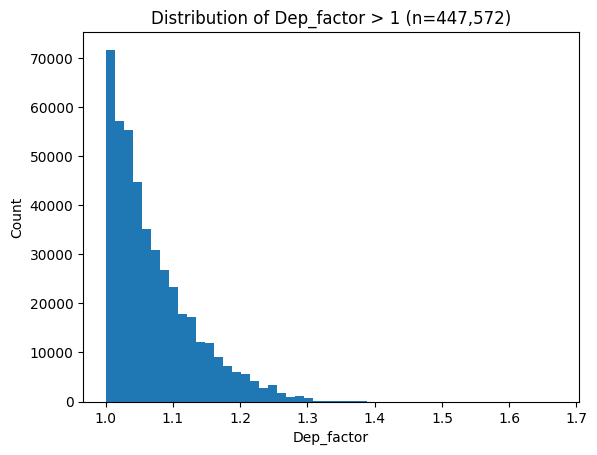

In [25]:
# Histogram of Dep_factor values > 1 only
dep_factor_above_1 = df[df['Dep_factor'] > 1]['Dep_factor'].dropna()
print(f"Records with Dep_factor > 1: {len(dep_factor_above_1):,}")
if len(dep_factor_above_1) > 0:
    plt.hist(dep_factor_above_1, bins=50)
    plt.xlabel('Dep_factor')
    plt.ylabel('Count')
    plt.title(f'Distribution of Dep_factor > 1 (n={len(dep_factor_above_1):,})')
    plt.show()
else:
    print('No records with Dep_factor > 1')

In [26]:

# Find whey dep factor gt than 1

print("KEY FINDINGS: Dep_factor > 1 Analysis")
print("_" * 70)


df_above_1 = df[df['Dep_factor'] > 1]
df_below_1 = df[df['Dep_factor'] <= 1]


metrics = {
    'Total Records': [len(df_above_1), len(df_below_1)],
    'Avg Age (years)': [df_above_1['CALC_VEH_AGE'].mean(), df_below_1['CALC_VEH_AGE'].mean()],
    'Avg Odometer': [df_above_1['cef_est_curr_mi_grp_imps'].mean(), df_below_1['cef_est_curr_mi_grp_imps'].mean()],
    'Avg Dep_factor': [df_above_1['Dep_factor'].mean(), df_below_1['Dep_factor'].mean()],
    '% Imputed Odometer': [(df_above_1['ODOMETER_IMP_FLAG'] == 1).mean() * 100, 
                           (df_below_1['ODOMETER_IMP_FLAG'] == 1).mean() * 100]
}

print(f"\n{'Metric':<25} {'Dep_factor > 1':>18} {'Dep_factor ≤ 1':>18}")
print("-" * 65)
for metric, values in metrics.items():
    if 'Records' in metric:
        print(f"{metric:<25} {values[0]:>18,} {values[1]:>18,}")
    elif 'Odometer' in metric and '%' not in metric:
        print(f"{metric:<25} {values[0]:>18,.0f} {values[1]:>18,.0f}")
    elif '%' in metric:
        print(f"{metric:<25} {values[0]:>17.1f}% {values[1]:>17.1f}%")
    else:
        print(f"{metric:<25} {values[0]:>18.1f} {values[1]:>18.1f}")


KEY FINDINGS: Dep_factor > 1 Analysis
______________________________________________________________________

Metric                        Dep_factor > 1     Dep_factor ≤ 1
-----------------------------------------------------------------
Total Records                        447,572         26,587,159
Avg Age (years)                          4.6               14.8
Avg Odometer                          15,227             89,830
Avg Dep_factor                           1.1                0.5
% Imputed Odometer                     31.9%              38.2%


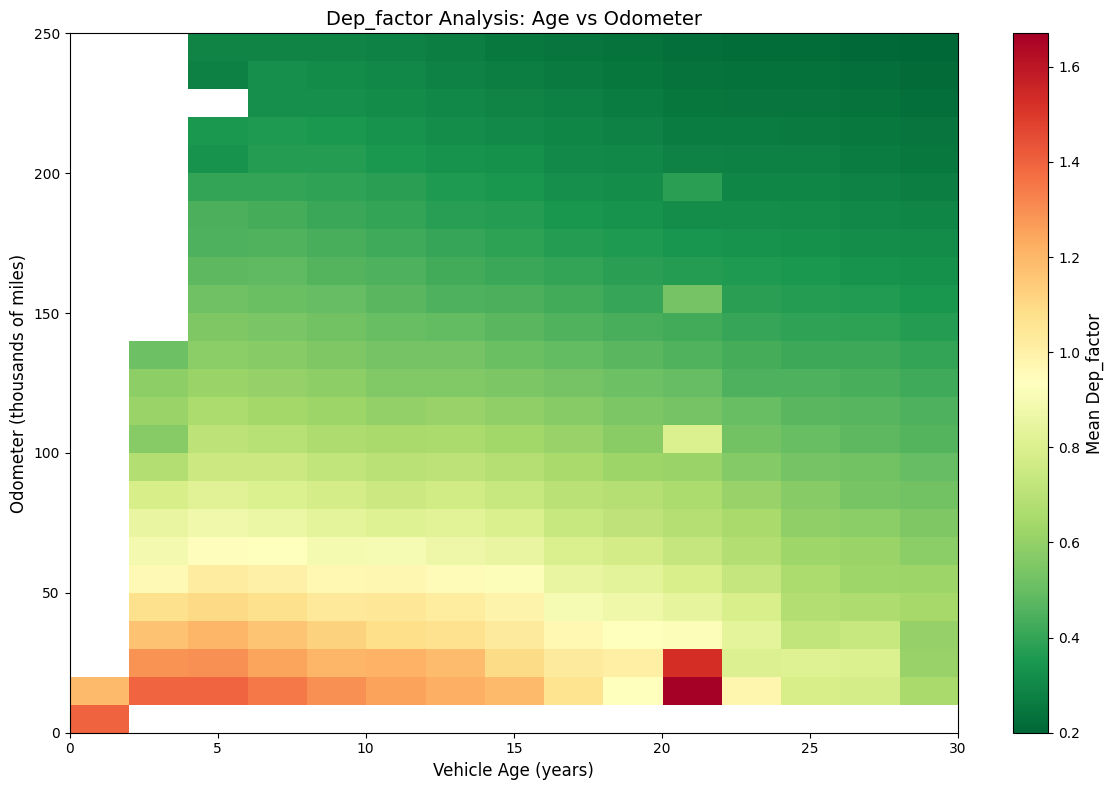

In [27]:
def plot_dep_factor_heatmap(df, age_col='CALC_VEH_AGE', odo_col='cef_est_curr_mi_grp_imps', 
                            dep_col='Dep_factor', title=None):
    """
    Plot a 2D heatmap of Dep_factor by Vehicle Age and Odometer.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import binned_statistic_2d
    
    # Prepare data - convert to float explicitly
    mask = df[age_col].notna() & df[odo_col].notna() & df[dep_col].notna()
    age = pd.to_numeric(df.loc[mask, age_col], errors='coerce').astype(float)
    odo = pd.to_numeric(df.loc[mask, odo_col], errors='coerce').astype(float) / 1000
    dep = pd.to_numeric(df.loc[mask, dep_col], errors='coerce').astype(float)
    
    # Remove any remaining NaN after conversion
    valid = age.notna() & odo.notna() & dep.notna()
    age, odo, dep = age[valid].values, odo[valid].values, dep[valid].values
    
    # Define bins
    age_bins = np.arange(0, 32, 2)
    odo_bins = np.arange(0, 251, 10)
    
    # Calculate mean Dep_factor for each bin
    stat, x_edge, y_edge, _ = binned_statistic_2d(
        age, odo, dep, statistic='max', bins=[age_bins, odo_bins]
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(stat.T, origin='lower', aspect='auto', cmap='RdYlGn_r',
                   extent=[age_bins[0], age_bins[-1], odo_bins[0], odo_bins[-1]],
                   vmin=0.2, vmax=max(1.0, dep.max()) )
    
    ax.set_xlabel('Vehicle Age (years)', fontsize=12)
    ax.set_ylabel('Odometer (thousands of miles)', fontsize=12)
    ax.set_title(title or f'Mean {dep_col} by Vehicle Age and Odometer', fontsize=14)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'Mean {dep_col}', fontsize=12)
    
    # try:
    #     ax.contour(stat.T, levels=[1.0], colors='black', linestyles='--', 
    #                extent=[age_bins[0], age_bins[-1], odo_bins[0], odo_bins[-1]])
    #     ax.text(0.02, 0.98, '--- Dep_factor = 1.0', transform=ax.transAxes, 
    #             fontsize=10, verticalalignment='top')
    # except:
    #     pass
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_dep_factor_heatmap(df, title='Dep_factor Analysis: Age vs Odometer')

In [28]:
suspicious = df[
    (df['CALC_VEH_AGE'] >= 18) & 
    (df['CALC_VEH_AGE'] <= 24) & 
    (df['Dep_factor'] > 1.2)  # Higher than expected
]

print(f"Suspicious records (age 18-24, Dep_factor > 1.2): {len(suspicious):,}")
print("\nBreakdown by odometer range:")
print(f"  < 50K miles: {len(suspicious[suspicious['cef_est_curr_mi_grp_imps'] < 50000]):,}")
print(f"  50K-150K: {len(suspicious[(suspicious['cef_est_curr_mi_grp_imps'] >= 50000) & (suspicious['cef_est_curr_mi_grp_imps'] < 150000)]):,}")
print(f"  > 150K miles: {len(suspicious[suspicious['cef_est_curr_mi_grp_imps'] >= 150000]):,}")


print("\nBSST distribution:")
print(suspicious['BSST_formatted'].value_counts().head(10))

print(f"\n% with ODOMETER_IMP_FLAG=1: {(suspicious['ODOMETER_IMP_FLAG'] == 1).mean() * 100:.1f}%")

print("\nSample records:")
print(suspicious[['CALC_VEH_AGE', 'cef_est_curr_mi_grp_imps', 'Dep_factor', 'BSST_formatted', 'ODOMETER_IMP_FLAG']].head(10))

Suspicious records (age 18-24, Dep_factor > 1.2): 20

Breakdown by odometer range:
  < 50K miles: 20
  50K-150K: 0
  > 150K miles: 0

BSST distribution:
BSST_formatted
Prestige_Sporty_Car_GLM    20
Name: count, dtype: int64

% with ODOMETER_IMP_FLAG=1: 0.0%

Sample records:
          CALC_VEH_AGE  cef_est_curr_mi_grp_imps Dep_factor  \
2275470           20.0                   10000.0   1.660102   
2559559           21.0                   10000.0   1.606472   
6984326           20.0                   10000.0   1.657058   
12793862          20.0                   10000.0   1.670492   
12884705          21.0                   10000.0   1.606472   
13410050          20.0                   20000.0    1.52922   
14786134          20.0                   10000.0   1.660102   
15927510          21.0                   10000.0   1.606472   
17419339          21.0                   10000.0   1.606472   
19029894          21.0                   10000.0   1.606472   

                   BSST_formatt

Total Prestige_Sporty_Car_GLM: 465,073

Age distribution:
count    465073.000000
mean         20.440997
std           8.887728
min           1.000000
25%          13.000000
50%          21.000000
75%          26.000000
max          45.000000
Name: CALC_VEH_AGE, dtype: float64

Suspicious (age >= 18, odo < 50K): 36,987


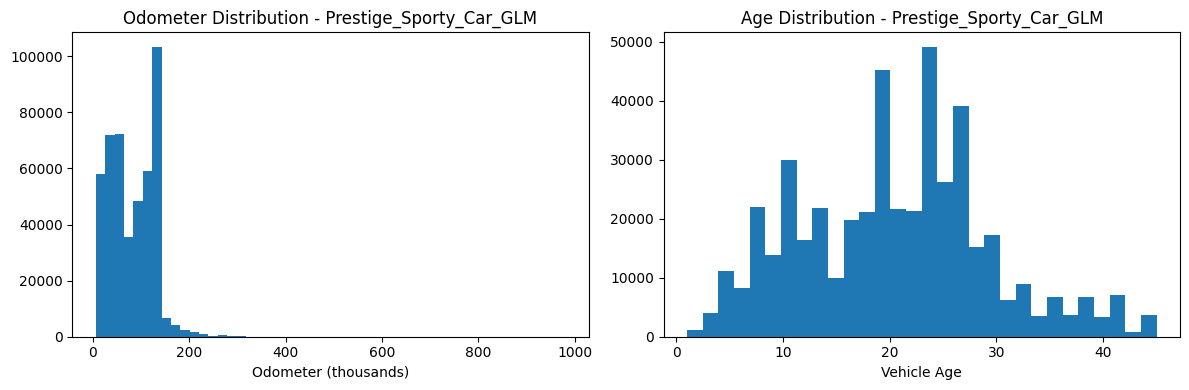


% with ODOMETER_IMP_FLAG=1 (suspicious): 0.0%
% with ODOMETER_IMP_FLAG=1 (all prestige): 52.5%


In [29]:
prestige = df[df['BSST_formatted'] == 'Prestige_Sporty_Car_GLM']
print(f"Total Prestige_Sporty_Car_GLM: {len(prestige):,}")

# Check age distribution
print("\nAge distribution:")
print(prestige['CALC_VEH_AGE'].describe())

# Filter to suspicious: age >= 18 AND odometer < 50K
suspicious = prestige[(prestige['CALC_VEH_AGE'] >= 18) & (prestige['cef_est_curr_mi_grp_imps'] < 50000)]
print(f"\nSuspicious (age >= 18, odo < 50K): {len(suspicious):,}")

# Histogram
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prestige['cef_est_curr_mi_grp_imps'] / 1000, bins=50)
axes[0].set_title('Odometer Distribution - Prestige_Sporty_Car_GLM')
axes[0].set_xlabel('Odometer (thousands)')
axes[1].hist(prestige['CALC_VEH_AGE'], bins=30)
axes[1].set_title('Age Distribution - Prestige_Sporty_Car_GLM')
axes[1].set_xlabel('Vehicle Age')
plt.tight_layout()
plt.show()

# Check ODOMETER_IMP_FLAG for suspicious records
print(f"\n% with ODOMETER_IMP_FLAG=1 (suspicious): {(suspicious['ODOMETER_IMP_FLAG'] == 1).mean() * 100:.1f}%")
print(f"% with ODOMETER_IMP_FLAG=1 (all prestige): {(prestige['ODOMETER_IMP_FLAG'] == 1).mean() * 100:.1f}%")

In [30]:
prestige_old = df[(df['BSST_formatted'] == 'Prestige_Sporty_Car_GLM') & (df['CALC_VEH_AGE'] >= 20)]
print(f"Records: {len(prestige_old):,}")
print(f"\nMSRP (vc_msrp_impa):")
print(prestige_old['vc_msrp_impa'].describe())
print(f"\nDep_factor:")
print(prestige_old['Dep_factor'].describe())
print(f"\nveh_value_dep:")
print(prestige_old['veh_value_dep'].describe())

Records: 262,644

MSRP (vc_msrp_impa):
count    262644.000000
mean      49474.537751
std       21360.744469
min       14750.000000
25%       37345.000000
50%       44175.000000
75%       55495.000000
max      320300.000000
Name: vc_msrp_impa, dtype: float64

Dep_factor:
count     262644.000000
unique     55492.000000
top            0.219906
freq         232.000000
Name: Dep_factor, dtype: float64

veh_value_dep:
count     262644.000000
unique     71609.000000
top         3000.798934
freq         195.000000
Name: veh_value_dep, dtype: float64


In [31]:
prestige_anomaly = df[
    (df['BSST_formatted'] == 'Prestige_Sporty_Car_GLM') & 
    (df['CALC_VEH_AGE'] >= 18) & 
    (df['Dep_factor'] > 1)
]
print(f"Prestige + Age>=18 + Dep_factor>1: {len(prestige_anomaly):,}")
print(prestige_anomaly[['CALC_VEH_AGE', 'cef_est_curr_mi_grp_imps', 'Dep_factor', 'ODOMETER_IMP_FLAG']].head(10))


Prestige + Age>=18 + Dep_factor>1: 20
          CALC_VEH_AGE  cef_est_curr_mi_grp_imps Dep_factor  ODOMETER_IMP_FLAG
2275470           20.0                   10000.0   1.660102                  0
2559559           21.0                   10000.0   1.606472                  0
6984326           20.0                   10000.0   1.657058                  0
12793862          20.0                   10000.0   1.670492                  0
12884705          21.0                   10000.0   1.606472                  0
13410050          20.0                   20000.0    1.52922                  0
14786134          20.0                   10000.0   1.660102                  0
15927510          21.0                   10000.0   1.606472                  0
17419339          21.0                   10000.0   1.606472                  0
19029894          21.0                   10000.0   1.606472                  0


In [32]:
# Define exclusion mask for prestige anomaly records
exclude_mask = (
    (df['BSST_formatted'] == 'Prestige_Sporty_Car_GLM') & 
    (df['CALC_VEH_AGE'] >= 18) & 
    (df['Dep_factor'] > 1)
)

# Save excluded records with vin tracking
df_excluded = df[exclude_mask][['vin_date', 'vin', 'CALC_VEH_AGE', 'cef_est_curr_mi_grp_imps', 'Dep_factor', 'ODOMETER_IMP_FLAG']].copy()
print(f"Excluding {len(df_excluded):,} Prestige_Sporty_Car_GLM anomaly records (age>=18 & Dep_factor>1)")
print(df_excluded.head(20))

# Create filtered dataframe for export (original df unchanged)
df_filtered = df[~exclude_mask].copy()
print(f"\nRecords for export: {len(df_filtered):,}")

Excluding 20 Prestige_Sporty_Car_GLM anomaly records (age>=18 & Dep_factor>1)
                              vin_date                vin  CALC_VEH_AGE  \
2275470   1FAFP90S36Y400968_01-01-2022  1FAFP90S36Y400968          20.0   
2559559   1FAFP90S85Y400088_07-01-2020  1FAFP90S85Y400088          21.0   
6984326   1FAFP90S46Y401112_01-01-2021  1FAFP90S46Y401112          20.0   
12793862  1FAFP90S76Y401394_08-30-2019  1FAFP90S76Y401394          20.0   
12884705  1FAFP90SX5Y401176_07-01-2022  1FAFP90SX5Y401176          21.0   
13410050  1FAFP90S56Y400647_07-01-2022  1FAFP90S56Y400647          20.0   
14786134  1FAFP90S26Y400072_01-01-2022  1FAFP90S26Y400072          20.0   
15927510  1FAFP90S45Y400573_04-01-2021  1FAFP90S45Y400573          21.0   
17419339  1FAFP90S25Y400944_10-01-2020  1FAFP90S25Y400944          21.0   
19029894  1FAFP90S35Y401634_01-01-2020  1FAFP90S35Y401634          21.0   
19029924  1FAFP90S25Y401818_10-01-2023  1FAFP90S25Y401818          21.0   
19033418  1FAFP90S86Y4

### CONCLUSION: Dep_factor > 1 is EXPECTED for low age, low-mileage vehicles
- Vehicles with Dep_factor > 1 are typically 4-5 years old with ~15K miles
- These vehicles have barely depreciated from MSRP


## Export Results to Parquet
Export selected columns to parquet file

In [33]:
# Validate required columns exist before export (using df_filtered)
required_columns = ['ODOMETER_IMP_FLAG', 'CALC_VEH_AGE', 'Dep_factor', 'veh_value_dep']
missing_cols = [col for col in required_columns if col not in df_filtered.columns]
if missing_cols:
    print(f"ERROR: Missing columns: {missing_cols}")
    print("Make sure you ran these cells in order:")
    print("  1. 'Apply all default values' cell (creates ODOMETER_IMP_FLAG, CALC_VEH_AGE)")
    print("  2. 'Process ALL BSST segments' cell (creates Dep_factor, veh_value_dep)")
    print("  3. 'Exclusion cell' (creates df_filtered)")
    raise KeyError(f"Missing required columns: {missing_cols}")

print("✓ All required columns present in df_filtered")
print(f"  df_filtered columns: {len(df_filtered.columns)}")
print(f"  df_filtered records: {len(df_filtered):,}")

# Define output columns in order
output_columns = [
    'vin_date',                        # First column
    'vin',
    'BODY_STYLE_SEGMENT_BODY_TYPE',    # BSST
    'cef_est_curr_mi_grp_imps',        # ODOMETER (with defaults applied)
    'ODOMETER_IMP_FLAG',               # Flag for imputed odometer values
    'CALC_VEH_AGE',
    'st_raw',                          # STATE (with defaults applied)
    'vc_msrp_impa',
    'Dep_factor',
    'veh_value_dep'
]

# Create output dataframe from filtered data
df_output = df_filtered[output_columns].copy()

# Rename columns for clarity in output
df_output = df_output.rename(columns={
    'cef_est_curr_mi_grp_imps': 'ODOMETER',
    'BODY_STYLE_SEGMENT_BODY_TYPE': 'BSST',
    'st_raw': 'STATE'
})

print("Output columns:")
print(df_output.columns.tolist())
print(f"\nOutput shape: {df_output.shape}")
print(f"\nData types:")
print(df_output.dtypes)

✓ All required columns present in df_filtered
  df_filtered columns: 18
  df_filtered records: 27,052,180
Output columns:
['vin_date', 'vin', 'BSST', 'ODOMETER', 'ODOMETER_IMP_FLAG', 'CALC_VEH_AGE', 'STATE', 'vc_msrp_impa', 'Dep_factor', 'veh_value_dep']

Output shape: (27052180, 10)

Data types:
vin_date              object
vin                   object
BSST                  object
ODOMETER             float64
ODOMETER_IMP_FLAG      int64
CALC_VEH_AGE         float64
STATE                 object
vc_msrp_impa         float64
Dep_factor            object
veh_value_dep         object
dtype: object


In [34]:
# Preview output
df_output.head(10)

,vin_date,vin,BSST,ODOMETER,ODOMETER_IMP_FLAG,CALC_VEH_AGE,STATE,vc_msrp_impa,Dep_factor,veh_value_dep
0,KMHWF35H45A178516_04-26-2022,KMHWF35H45A178516,Lower Midsize (Car),108144.0,1,21.0,OH,19594.0,0.321679,6302.978516
1,KMHWF35H75A128502_11-21-2020,KMHWF35H75A128502,Lower Midsize (Car),210000.0,0,21.0,TX,19594.0,0.185452,3633.740971
2,KMHD35LE5DU068088_05-03-2020,KMHD35LE5DU068088,Basic Economy (Car),70000.0,0,13.0,CA,19545.0,0.601815,11762.475273
3,KMHD35LE5DU047158_05-30-2021,KMHD35LE5DU047158,Basic Economy (Car),60000.0,0,13.0,GA,18545.0,0.621969,11534.422334
4,KMHD35LE5DU082332_11-17-2019,KMHD35LE5DU082332,Basic Economy (Car),58921.0,1,13.0,NJ,18545.0,0.595088,11035.900521
5,KMHD35LE5DU082332_11-17-2019,KMHD35LE5DU082332,Basic Economy (Car),58921.0,1,13.0,NJ,18545.0,0.595088,11035.900521
6,1HGCP3F81BA000806_05-11-2024,1HGCP3F81BA000806,Lower Midsize (Car),130000.0,0,15.0,NC,29630.0,0.388005,11496.58139
7,KMHD04LB4JU724186_07-24-2020,KMHD04LB4JU724186,Basic Economy (Car),10000.0,0,8.0,CA,22900.0,0.925535,21194.760238
8,KMHWF35H83A750166_08-31-2021,KMHWF35H83A750166,Lower Midsize (Car),117590.0,1,23.0,OH,19114.0,0.288971,5523.396385
9,KMHD35LE9DU147828_02-12-2021,KMHD35LE9DU147828,Basic Economy (Car),200000.0,0,13.0,OH,18545.0,0.281523,5220.843477


In [35]:
# Export to parquet (using output_path from config)
print(f"Exporting to: {short_path(output_path)}")
df_output.to_parquet(output_path, index=False)

# Verify export
file_size = os.path.getsize(output_path) / (1024 * 1024)  # Size in MB
print(f"\n✓ Export complete!")
print(f"  File size: {file_size:.2f} MB")
print(f"  Records: {len(df_output):,}")
print(f"  Columns: {len(df_output.columns)}")

Exporting to: ~/dev/aps/data/2026_Dmodel_data/car_with_dep_factor.parquet

✓ Export complete!
  File size: 1225.39 MB
  Records: 27,052,180
  Columns: 10


In [36]:
# Verify by reading back
df_verify = pd.read_parquet(output_path)
print(f"Verification - read back {len(df_verify):,} records")
print(f"\nODOMETER_IMP_FLAG distribution:")
print(df_verify['ODOMETER_IMP_FLAG'].value_counts())
print(f"\nRecords with imputed odometer: {(df_verify['ODOMETER_IMP_FLAG'] == 1).sum():,}")

Verification - read back 27,052,180 records

ODOMETER_IMP_FLAG distribution:
ODOMETER_IMP_FLAG
0    16743718
1    10308462
Name: count, dtype: int64

Records with imputed odometer: 10,308,462
